# Predicting Heart Disease — EDA & Baseline Model
**Author:** Viswanath Nuggu | **Date:** March 2026
**Dataset:** Kaggle Playground Series S6E2 — Predicting Heart Disease

> **Research Question:** Can a machine learning model accurately predict the presence or absence of heart disease in a patient based on their clinical measurements and diagnostic test results, and which factors are most strongly associated with that risk?

---
**Table of Contents**
1. Setup & Data Loading
2. Data Overview
3. Data Cleaning (Duplicates & Missing Values)
4. Target Variable Distribution
5. Numeric Feature Distributions
6. Boxplot Analysis
7. Correlation Heatmap
8. Categorical Feature Analysis
9. Scatter Analysis
10. Outlier Analysis (IQR Method)
11. Feature Engineering
12. Advanced Visualization — Thallium × Chest Pain Type
13. Baseline Model — Logistic Regression
14. Confusion Matrix
15. ROC Curve
16. Feature Importance
17. Summary & Next Steps


## 1. Setup & Data Loading

In [1]:
import pandas as pd                         
import numpy as np                           
import matplotlib.pyplot as plt           
import matplotlib.cm as cm
import seaborn as sns                        
import plotly.express as px                  

# Scikit-learn: preprocessing, modeling, and evaluation
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    accuracy_score, precision_score, recall_score, f1_score
)

# Set global plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

# Load datasets 
df   = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

print(f"Training set : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Test set     : {test.shape[0]:,} rows × {test.shape[1]} columns")
df.head()

Training set : 630,000 rows × 15 columns
Test set     : 270,000 rows × 14 columns


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


## 2. Data Overview

In [2]:
# Inspect column names, data types, and memory usage
print("=== DATA TYPES ===")
print(df.dtypes)
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

=== DATA TYPES ===
id                           int64
Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
Heart Disease               object
dtype: object

Memory usage: 111.2 MB


In [3]:

df.describe().round(2)

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00
mean,314999.50,54.14,0.71,3.31,130.50,245.01,0.08,0.98,152.82,0.27,0.72,1.46,0.45,4.62
std,181865.48,8.26,0.45,0.85,14.98,33.68,0.27,1.00,19.11,0.45,0.95,0.55,0.80,1.95
min,0.00,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00
25%,157499.75,48.00,0.00,3.00,120.00,223.00,0.00,0.00,142.00,0.00,0.00,1.00,0.00,3.00
50%,314999.50,54.00,1.00,4.00,130.00,243.00,0.00,0.00,157.00,0.00,0.10,1.00,0.00,3.00
75%,472499.25,60.00,1.00,4.00,140.00,269.00,0.00,2.00,166.00,1.00,1.40,2.00,1.00,7.00
max,629999.00,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00


## 3. Data Cleaning — Missing Values & Duplicates

In [4]:

print("=== MISSING VALUES PER COLUMN ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "No missing values found in any column.")

# Check for duplicate rows (excluding id and target) 
feature_cols_check = [c for c in df.columns if c not in ['id', 'Heart Disease']]
n_duplicates = df.duplicated(subset=feature_cols_check).sum()
print(f"\n=== DUPLICATE ROWS ===")
print(f"Duplicate rows (based on feature columns): {n_duplicates:,}")

# Since no duplicates found, retain the full dataset
df_clean = df.copy()
print(f"\nDataset shape after cleaning: {df_clean.shape}")

=== MISSING VALUES PER COLUMN ===


No missing values found in any column.

=== DUPLICATE ROWS ===
Duplicate rows (based on feature columns): 0



Dataset shape after cleaning: (630000, 15)


> **Cleaning Result:** The dataset is already clean — no missing values and no duplicate records across all 630,000 rows. No imputation or row removal was required.

## 4. Target Variable Distribution

In [5]:
# Encode target as binary integer for modeling (Presence=1, Absence=0)
df_clean['target'] = (df_clean['Heart Disease'] == 'Presence').astype(int)

# Class balance check
print("=== CLASS DISTRIBUTION ===")
print(df_clean['Heart Disease'].value_counts())
print()
print(df_clean['Heart Disease'].value_counts(normalize=True).round(4))

=== CLASS DISTRIBUTION ===
Heart Disease
Absence     347546
Presence    282454
Name: count, dtype: int64

Heart Disease
Absence     0.5517
Presence    0.4483
Name: proportion, dtype: float64


In [6]:
# Display: Target Class Distribution

> **Observation:** The classes are nearly balanced — 55.2% Absence vs 44.8% Presence. No resampling (e.g., SMOTE) is required. This is ideal for straightforward binary classification.

## 5. Numeric Feature Distributions by Target

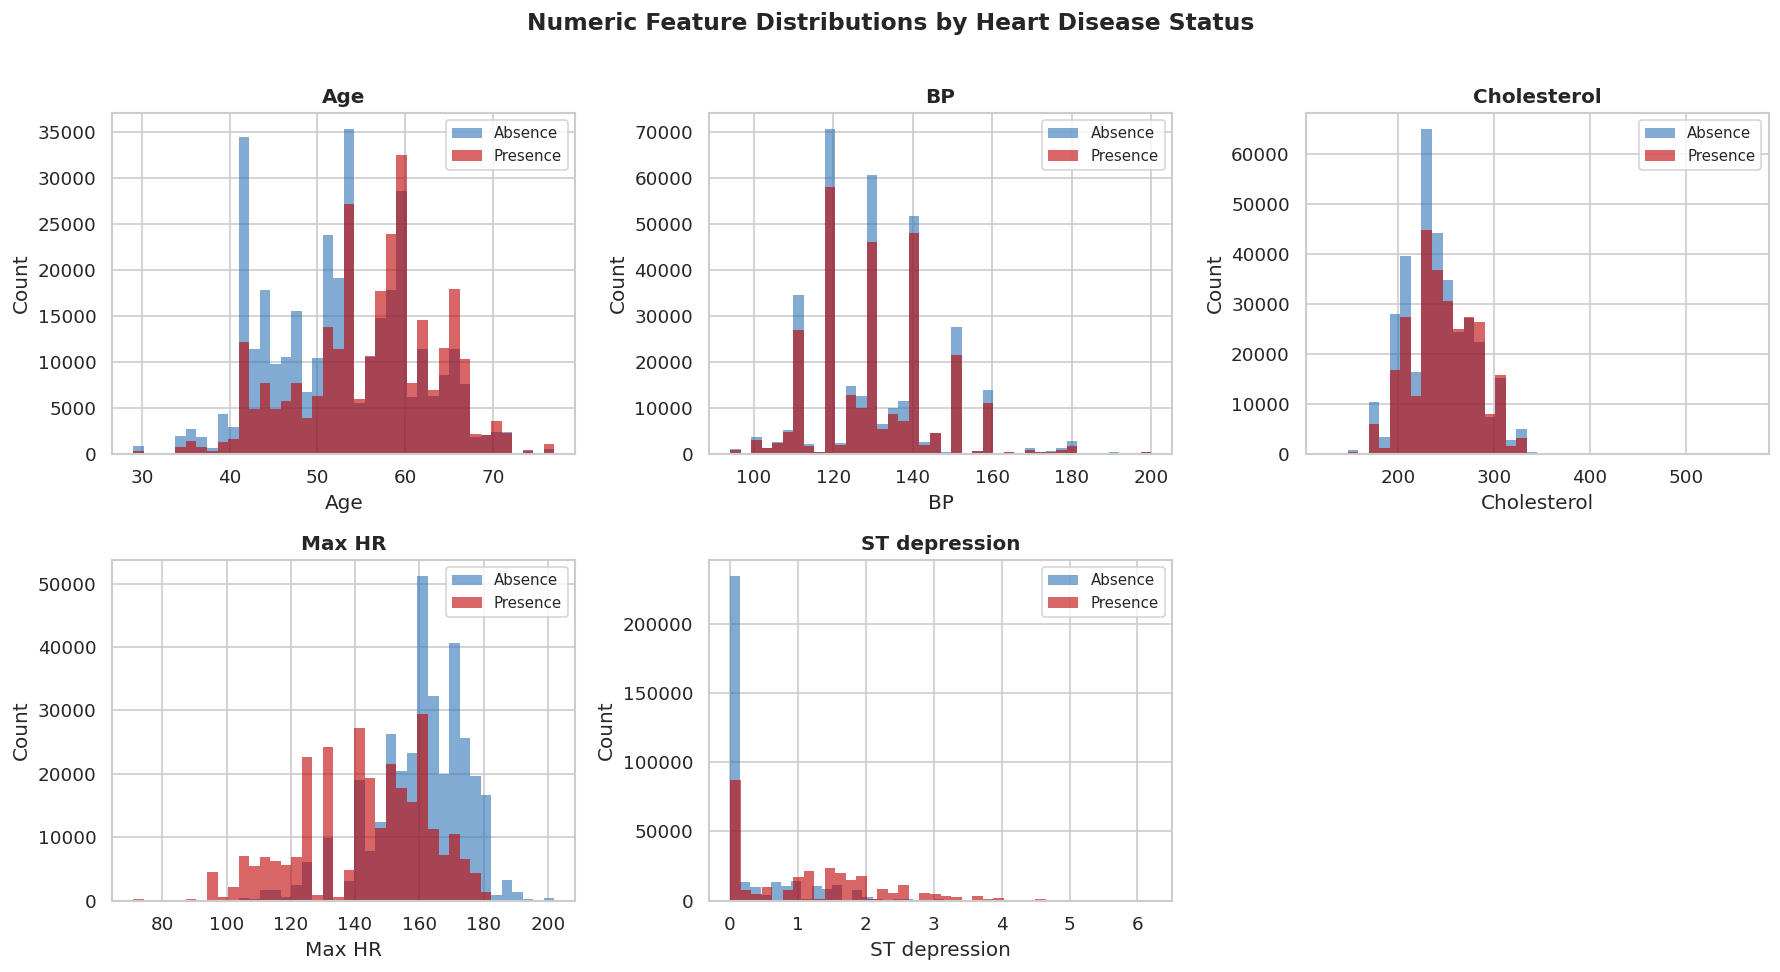

In [7]:
# Overlay histograms for each numeric feature split by target class
num_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
colors = {'Absence': '#2E74B5', 'Presence': '#C00000'}

for i, col in enumerate(num_cols):
    for label, color in colors.items():
        subset = df_clean[df_clean['Heart Disease'] == label][col]
        axes[i].hist(subset, bins=40, alpha=0.6, color=color, label=label, edgecolor='none')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=9)

axes[-1].set_visible(False)  # hide unused subplot
plt.suptitle('Numeric Feature Distributions by Heart Disease Status', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [8]:
# Display: Numeric Distributions

**Key Observations:**
- **Age:** Heart disease patients tend to be older (peak ~57) vs Absence (peak ~51).
- **Max HR:** The clearest separation — lower max heart rate strongly predicts Presence.
- **ST Depression:** Higher values clearly skew toward Presence.
- **BP & Cholesterol:** Overlap between classes — moderate discriminators on their own.


## 6. Boxplot Analysis

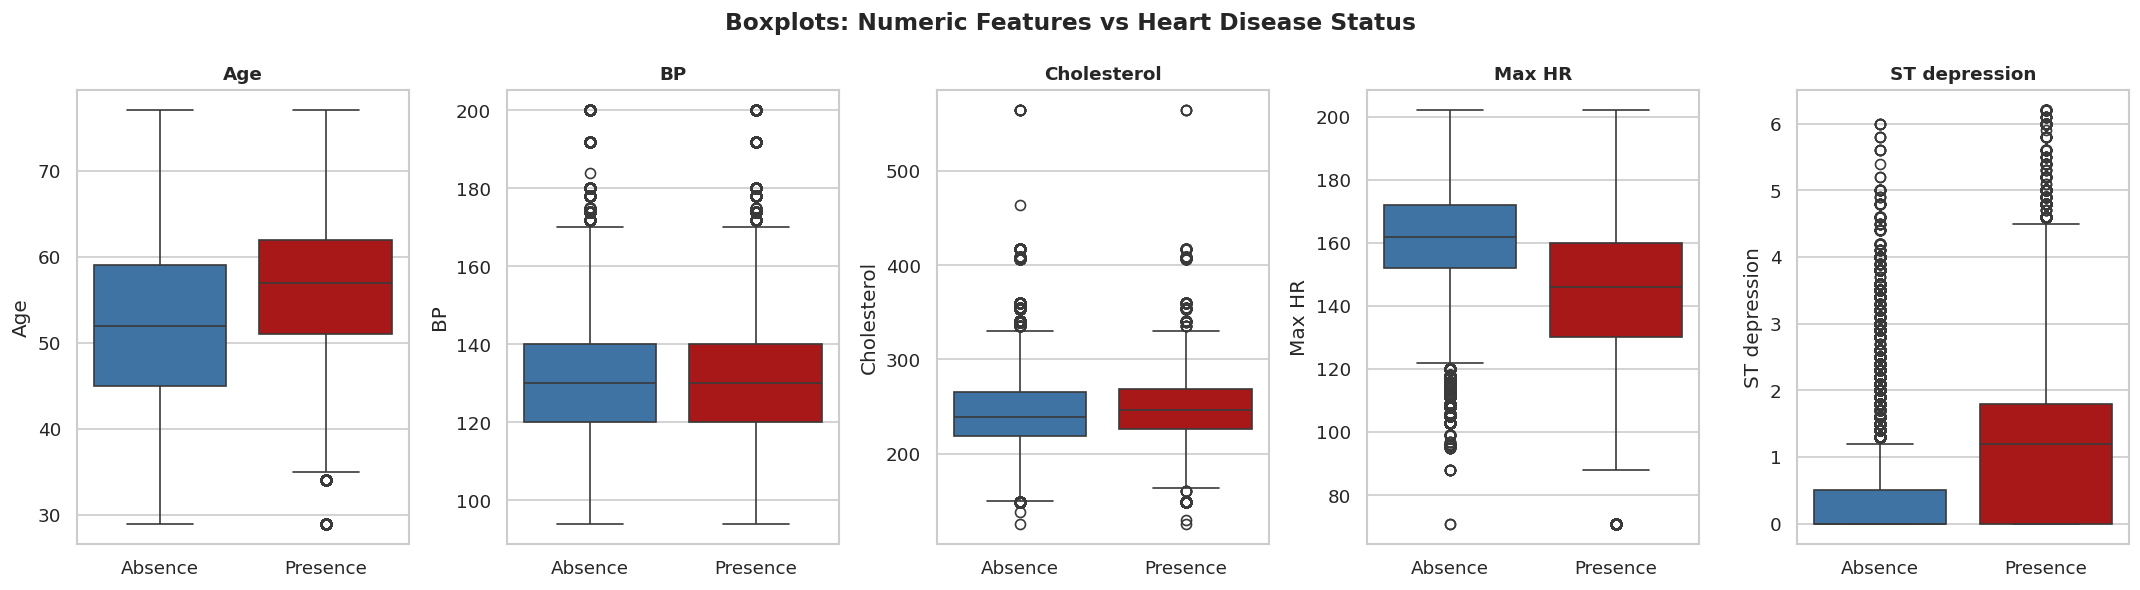

In [9]:
# Boxplots show median, IQR, and whisker range per class for each numeric feature
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for i, col in enumerate(num_cols):
    sns.boxplot(data=df_clean, x='Heart Disease', y=col,
                hue='Heart Disease', palette={'Absence':'#2E74B5','Presence':'#C00000'},
                order=['Absence','Presence'], ax=axes[i], legend=False)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Boxplots: Numeric Features vs Heart Disease Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# Display: Boxplots

**Key Observations:**
- **Max HR** shows the clearest separation — significantly lower in the Presence group.
- **ST Depression** is markedly higher in the Presence group (median ~1.5 vs ~0).
- **Age** shows moderate separation — Presence patients tend to be ~6 years older on median.
- **BP** and **Cholesterol** show less separation; both classes overlap substantially.


## 7. Correlation Heatmap

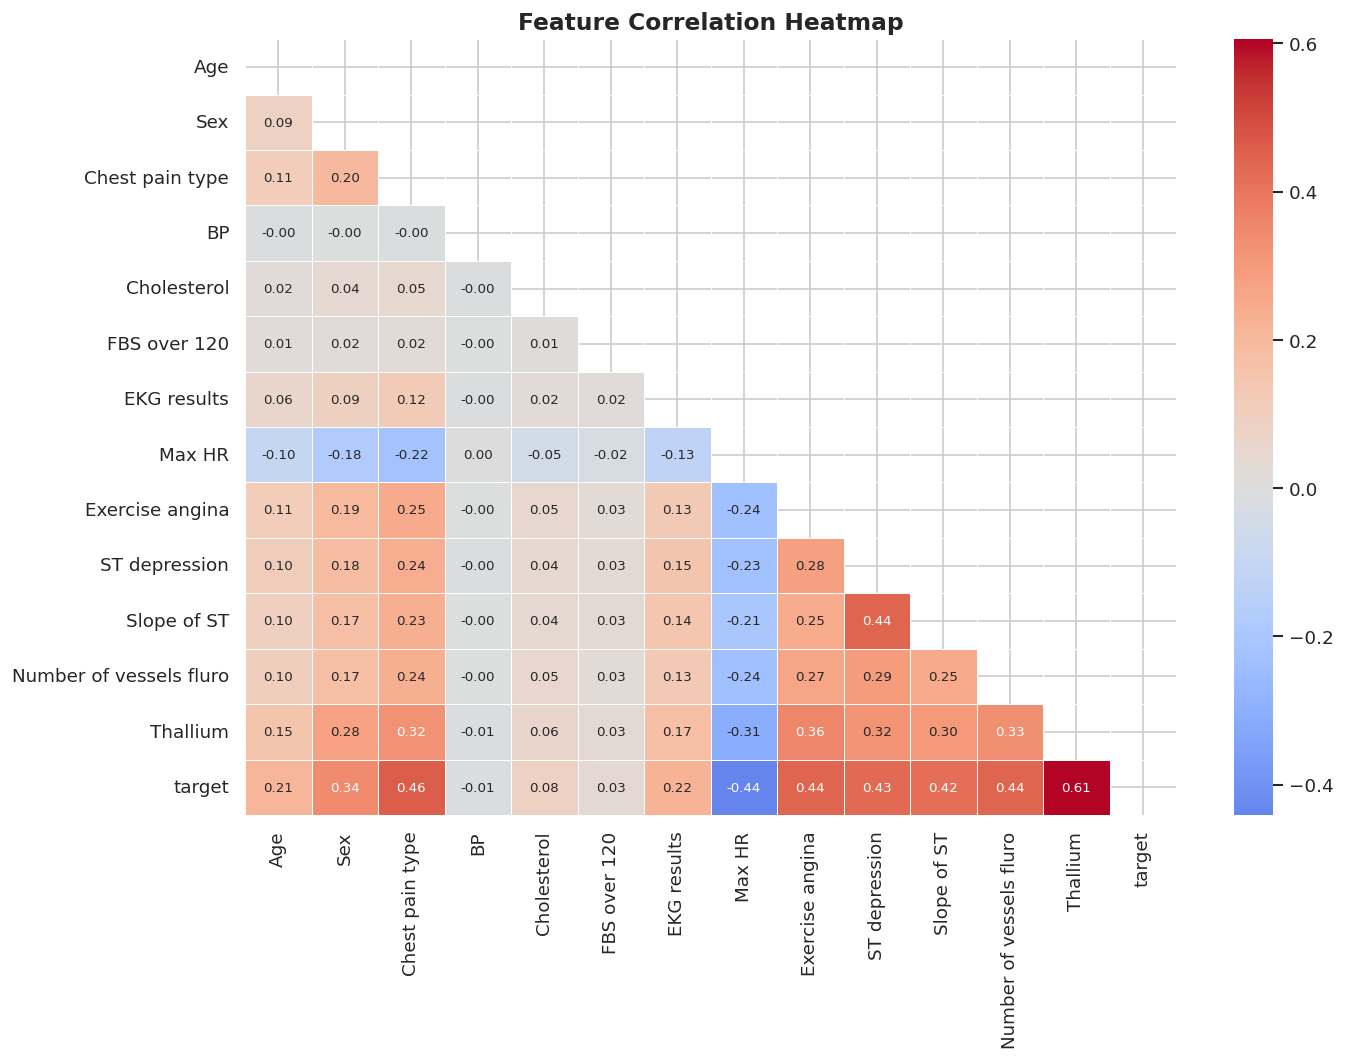

In [11]:
# Compute correlations between all numeric features including the binary target
corr_df = df_clean.drop(columns=['id', 'Heart Disease'])
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # show lower triangle only
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            ax=ax, annot_kws={'size': 8})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# Display: Correlation Heatmap

**Key Observations:**
- `Thallium`, `Chest pain type`, and `Number of vessels fluro` are most positively correlated with the target.
- `Max HR` is negatively correlated — higher max HR is associated with Absence.
- No severe multicollinearity detected between features (all inter-feature correlations < 0.7).


## 8. Categorical Feature Analysis

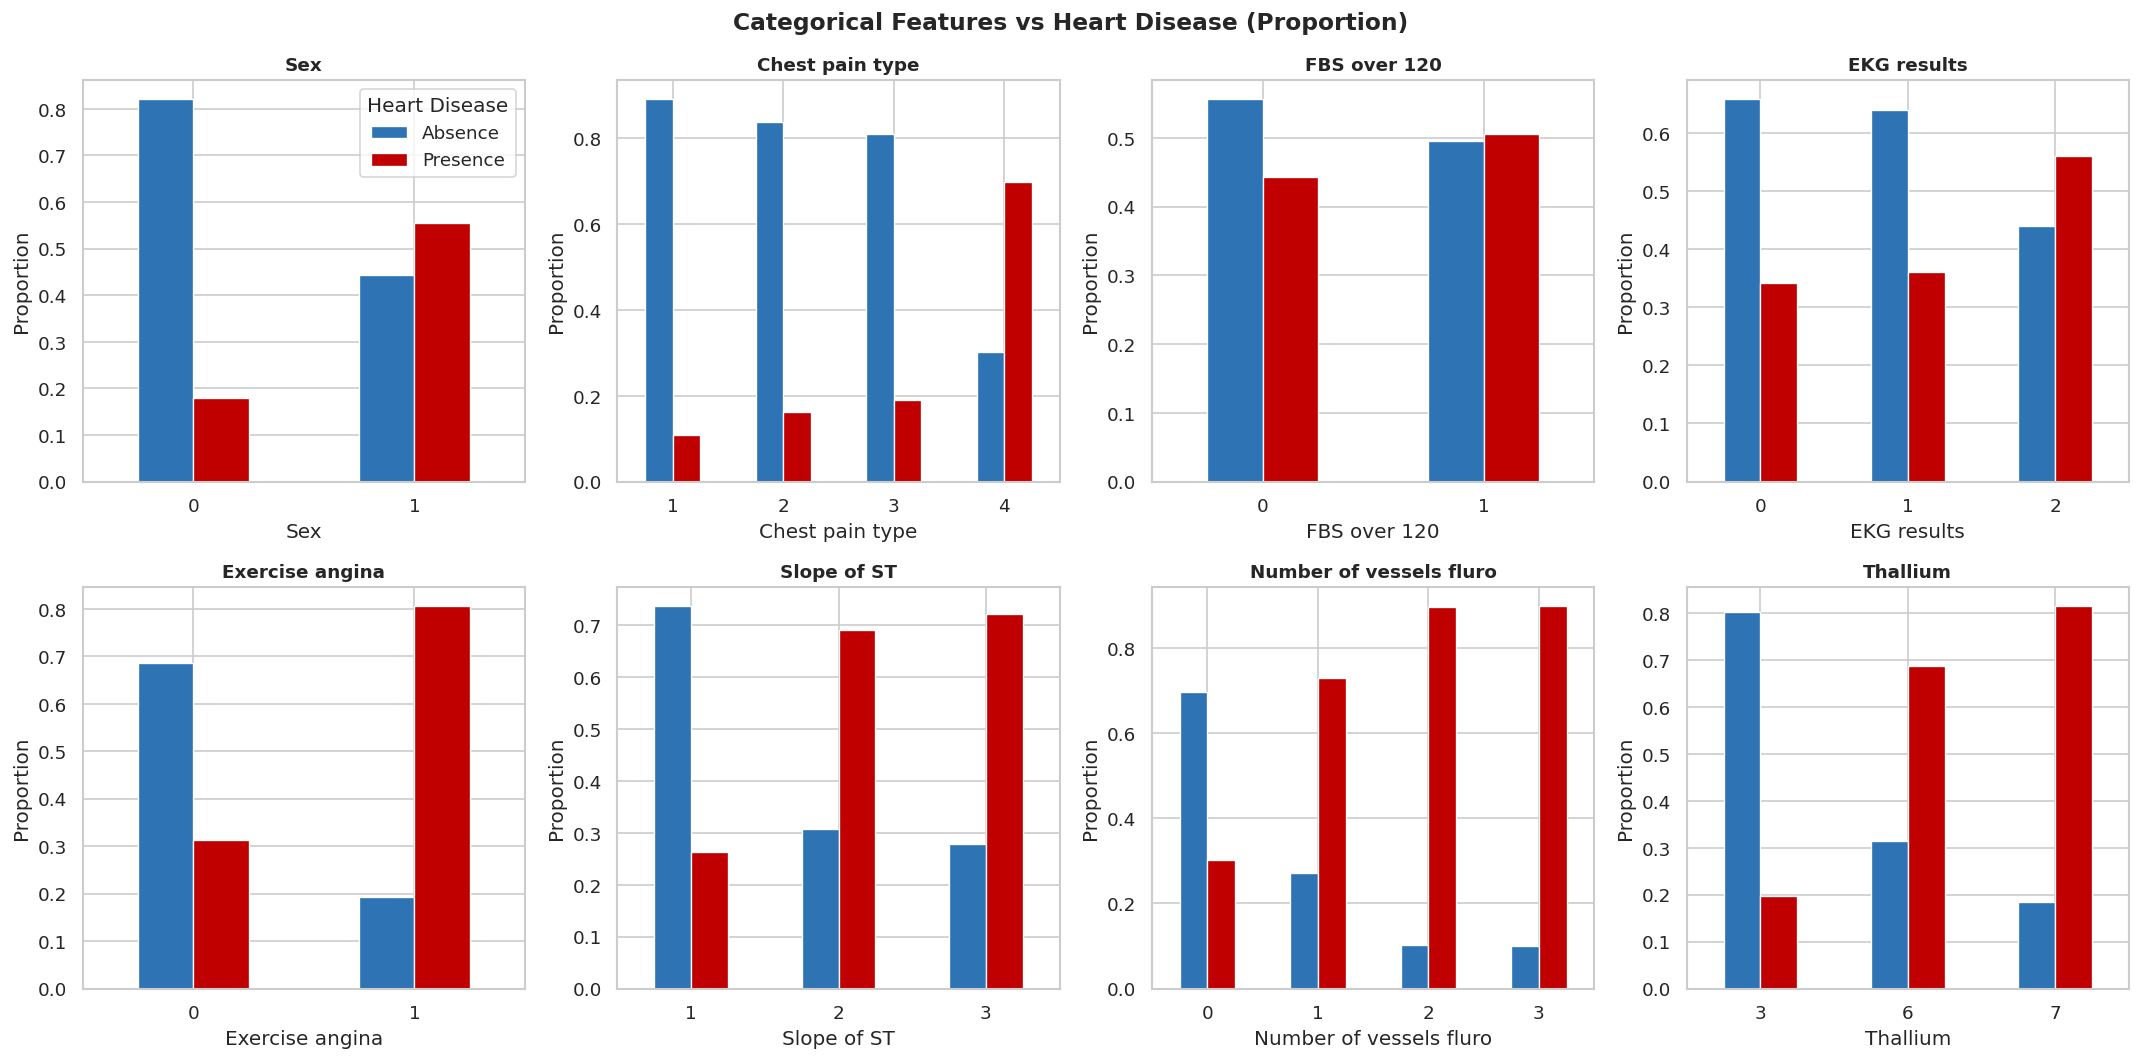

In [13]:
# Stacked proportional bar charts for all binary/ordinal categorical features
cat_cols = ['Sex','Chest pain type','FBS over 120','EKG results',
            'Exercise angina','Slope of ST','Number of vessels fluro','Thallium']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # Cross-tabulate and normalize by row to get proportions
    ct = df_clean.groupby([col, 'Heart Disease']).size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0)
    ct_pct.plot(kind='bar', ax=axes[i], color=['#2E74B5','#C00000'],
                edgecolor='white', linewidth=0.8, legend=(i == 0))
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Proportion')
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Categorical Features vs Heart Disease (Proportion)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# Display: Categorical Features

**Key Observations:**
- **Chest Pain Type 4** (asymptomatic): overwhelming proportion of Presence cases.
- **Exercise Angina = 1**: strongly associated with Presence.
- **Thallium = 7** (reversible defect): very high Presence proportion.
- **Number of Vessels Fluro**: more vessels colored = higher disease rate.
- **Sex = 1 (Male)**: higher disease prevalence than Female in this dataset.


## 9. Scatter Analysis — Age vs Max Heart Rate

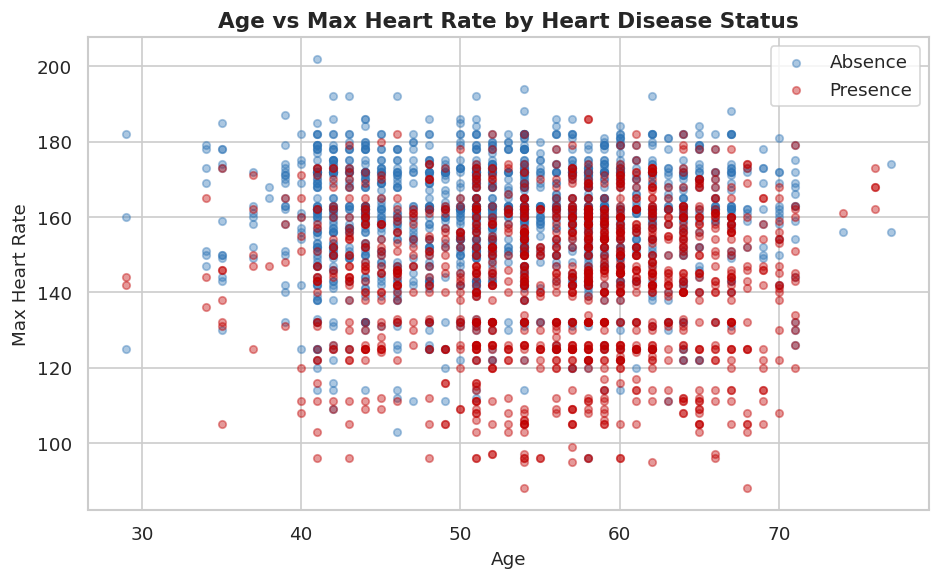

In [15]:
# Sample 3,000 rows for readability; plot Age vs Max HR colored by target
sample = df_clean.sample(3000, random_state=42)

fig, ax = plt.subplots(figsize=(8, 5))
for label, color in {'Absence':'#2E74B5','Presence':'#C00000'}.items():
    s = sample[sample['Heart Disease'] == label]
    ax.scatter(s['Age'], s['Max HR'], alpha=0.4, color=color, label=label, s=20)

ax.set_xlabel('Age', fontsize=11)
ax.set_ylabel('Max Heart Rate', fontsize=11)
ax.set_title('Age vs Max Heart Rate by Heart Disease Status', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
# Display: Age vs Max HR Scatter

> **Observation:** Older patients with lower max heart rate cluster strongly in the Presence group. This two-feature combination provides clear visual class separation.

## 10. Outlier Analysis — IQR Method

In [17]:
# Identify outliers using the 1.5×IQR rule for each numeric feature
num_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']
outlier_results = []

for col in num_cols:
    Q1  = df_clean[col].quantile(0.25)
    Q3  = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR   # Anything below this is a potential outlier
    upper_bound = Q3 + 1.5 * IQR   # Anything above this is a potential outlier
    n_outliers  = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
    outlier_results.append({
        'Feature'      : col,
        'Q1'           : round(Q1, 1),
        'Q3'           : round(Q3, 1),
        'IQR'          : round(IQR, 1),
        'Lower Bound'  : round(lower_bound, 1),
        'Upper Bound'  : round(upper_bound, 1),
        'Outlier Count': n_outliers,
        'Outlier %'    : round(n_outliers / len(df_clean) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_results)
print(outlier_df.to_string(index=False))

      Feature    Q1    Q3  IQR  Lower Bound  Upper Bound  Outlier Count  Outlier %
          Age  48.0  60.0 12.0         30.0         78.0           1048       0.17
           BP 120.0 140.0 20.0         90.0        170.0           9011       1.43
  Cholesterol 223.0 269.0 46.0        154.0        338.0           2194       0.35
       Max HR 142.0 166.0 24.0        106.0        202.0          14246       2.26
ST depression   0.0   1.4  1.4         -2.1          3.5           9971       1.58


In [18]:
# Display: Outlier Analysis

**Outlier Decision:**
- Outlier percentages are small (0.17%–2.26%) and reflect **clinically valid extreme values** (e.g., very high BP or cholesterol exist in real patients).
- These values are **retained** — removing them would bias the model and reduce coverage of genuine high-risk patients.
- The model will use `StandardScaler` normalization which reduces the influence of extreme values without discarding them.


## 11. Feature Engineering

In [19]:
# Create clinically-motivated binary threshold features
df_clean['High_Cholesterol'] = (df_clean['Cholesterol'] > 240).astype(int)  # Borderline-high per AHA guidelines
df_clean['High_BP']          = (df_clean['BP'] >= 140).astype(int)           # Stage 2 hypertension threshold
df_clean['Low_MaxHR']        = (df_clean['Max HR'] < 120).astype(int)        # Reduced cardiac response

# Age group bins for categorical analysis 
df_clean['Age_group'] = pd.cut(df_clean['Age'],
                               bins=[0, 40, 50, 60, 70, 100],
                               labels=['<40','40-50','50-60','60-70','70+'])

# Composite risk score: sum of binary risk indicators 
# Higher score = more simultaneous risk factors present
df_clean['Risk_score'] = (df_clean['Sex']             +   
                          df_clean['FBS over 120']     +   
                          df_clean['Exercise angina']  +   
                          df_clean['High_Cholesterol'] +   
                          df_clean['High_BP']          +   
                          df_clean['Low_MaxHR'])            

# Validate: show disease rate at each risk score level 
print("Risk Score → Heart Disease Rate:")
print(df_clean.groupby('Risk_score')['target'].mean().apply(lambda x: f'{x:.1%}'))

Risk Score → Heart Disease Rate:
Risk_score
0     9.5%
1    24.7%
2    44.7%
3    67.0%
4    85.0%
5    93.7%
6    97.4%
Name: target, dtype: object


In [20]:
# Display: Risk Score

> **Insight:** The Risk Score shows a near-perfect monotonic relationship with disease rate — from 9.5% at score 0 to 97.4% at score 6. This validates the additive nature of clinical risk factors.

## 12. Advanced Visualization — Thallium × Chest Pain Type
*(Using Plotly-style grouped bar — rendered via Matplotlib)*

In [21]:

import plotly.express as px

pivot = df_clean.groupby(['Thallium','Chest pain type'])['target'].mean().reset_index()
pivot.columns = ['Thallium','Chest Pain Type','Heart Disease Rate']
pivot['Heart Disease Rate'] = (pivot['Heart Disease Rate'] * 100).round(1)
pivot['Chest Pain Type'] = pivot['Chest Pain Type'].astype(str)
pivot['Thallium_label'] = pivot['Thallium'].map({3:'3=Normal',6:'6=Fixed Defect',7:'7=Reversible Defect'})

# Plotly interactive figure (renders interactively in Jupyter)
fig = px.bar(pivot, x='Thallium_label', y='Heart Disease Rate',
             color='Chest Pain Type', barmode='group',
             title='Heart Disease Rate (%) by Thallium Result & Chest Pain Type',
             labels={'Thallium_label':'Thallium Result', 'Heart Disease Rate':'Disease Rate (%)'},
             color_discrete_sequence=px.colors.qualitative.Set2,
             text='Heart Disease Rate', height=450)
fig.update_traces(texttemplate='%{text}%', textposition='outside')
fig.update_layout(yaxis_range=[0,110], plot_bgcolor='white', paper_bgcolor='white')
fig.show()

In [22]:
# Display: Thallium x Chest Pain Grouped Bar

**Key Insight:** Patients with **Thallium = 7 (Reversible Defect)** AND **Chest Pain Type 4 (Asymptomatic)** have the highest heart disease rates — above 90%. Normal Thallium results (3) show low disease rates across all chest pain types. These two features together are highly discriminative.


## 13. Baseline Model — Logistic Regression

### Why Logistic Regression?
Logistic Regression is the standard baseline for binary classification tasks. It is interpretable, fast to train even on large datasets, and its coefficients directly indicate the direction and magnitude of each feature's contribution to the prediction.

### Why ROC-AUC as the Evaluation Metric?
ROC-AUC (Area Under the Receiver Operating Characteristic Curve) is the preferred metric for this task because:
1. **Class imbalance robustness:** Unlike accuracy, ROC-AUC is insensitive to class imbalance — it measures the model's ability to discriminate between classes across all decision thresholds.
2. **Clinical relevance:** In medical screening, the cost of a false negative (missing a sick patient) is different from a false positive. ROC-AUC captures the full tradeoff between sensitivity (recall) and specificity.
3. **Competition standard:** The Kaggle competition uses ROC-AUC as the official scoring metric.
4. **Interpretability:** An AUC of 0.5 = random guessing; 1.0 = perfect classifier — easy to communicate to non-technical stakeholders.


In [23]:
# Define feature set including engineered variables 
feature_cols = ['Age','Sex','Chest pain type','BP','Cholesterol',
                'FBS over 120','EKG results','Max HR','Exercise angina',
                'ST depression','Slope of ST','Number of vessels fluro',
                'Thallium','High_Cholesterol','High_BP','Low_MaxHR','Risk_score']

X = df_clean[feature_cols]
y = df_clean['target']

# Stratified 80/20 split to maintain class proportions 
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Normalize features: required for Logistic Regression
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)   # fit on train only to avoid data leakage
X_val_sc    = scaler.transform(X_val)

# Train Logistic Regression 
lr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr.fit(X_train_sc, y_train)

# Generate predictions
y_pred  = lr.predict(X_val_sc)
y_proba = lr.predict_proba(X_val_sc)[:, 1]   # probability of Presence

# Print evaluation metrics
print("=" * 48)
print("  LOGISTIC REGRESSION — VALIDATION RESULTS")
print("=" * 48)
print(f"  Accuracy  : {accuracy_score(y_val, y_pred):.4f}")
print(f"  Precision : {precision_score(y_val, y_pred):.4f}")
print(f"  Recall    : {recall_score(y_val, y_pred):.4f}")
print(f"  F1 Score  : {f1_score(y_val, y_pred):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_val, y_proba):.4f}")
print("=" * 48)
print()
print(classification_report(y_val, y_pred, target_names=['Absence','Presence']))

  LOGISTIC REGRESSION — VALIDATION RESULTS
  Accuracy  : 0.8850
  Precision : 0.8816
  Recall    : 0.8589
  F1 Score  : 0.8701
  ROC-AUC   : 0.9516

              precision    recall  f1-score   support

     Absence       0.89      0.91      0.90     69509
    Presence       0.88      0.86      0.87     56491

    accuracy                           0.89    126000
   macro avg       0.88      0.88      0.88    126000
weighted avg       0.88      0.89      0.88    126000



## 14. Confusion Matrix

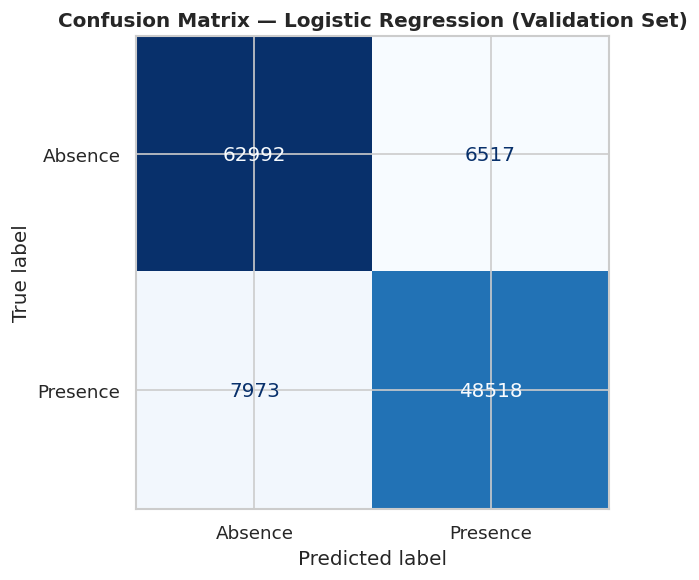

In [24]:
# Confusion matrix shows true/false positive and negative counts
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Absence','Presence'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Logistic Regression (Validation Set)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
# Display: Confusion Matrix

> **Interpretation:** The model correctly identifies the majority of both Presence and Absence cases. False negatives (missed Presence cases) are ~14% of actual Presence — a key area for improvement in the advanced model.

## 15. ROC Curve

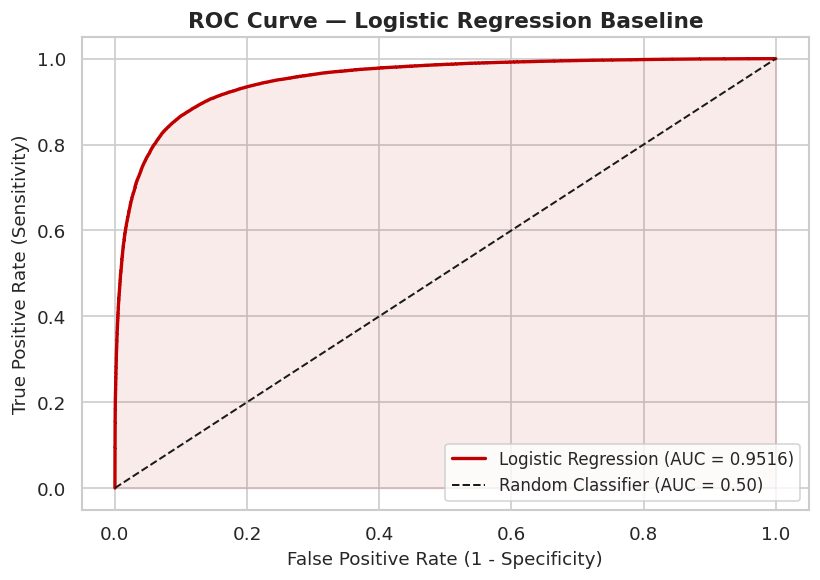

In [26]:
# ROC curve plots True Positive Rate vs False Positive Rate at all thresholds
fpr, tpr, thresholds = roc_curve(y_val, y_proba)
auc_score = roc_auc_score(y_val, y_proba)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='#C00000', lw=2,
        label=f'Logistic Regression (AUC = {auc_score:.4f})')
ax.plot([0,1],[0,1], 'k--', lw=1.2, label='Random Classifier (AUC = 0.50)')
ax.fill_between(fpr, tpr, alpha=0.08, color='#C00000')
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=11)
ax.set_title('ROC Curve — Logistic Regression Baseline', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

In [27]:
# Display: ROC Curve

> **Result:** ROC-AUC = **0.9516**, significantly above our target of 0.90. This means the model correctly ranks a randomly selected Presence patient above a randomly selected Absence patient 95.16% of the time.

## 16. Feature Importance — Logistic Regression Coefficients

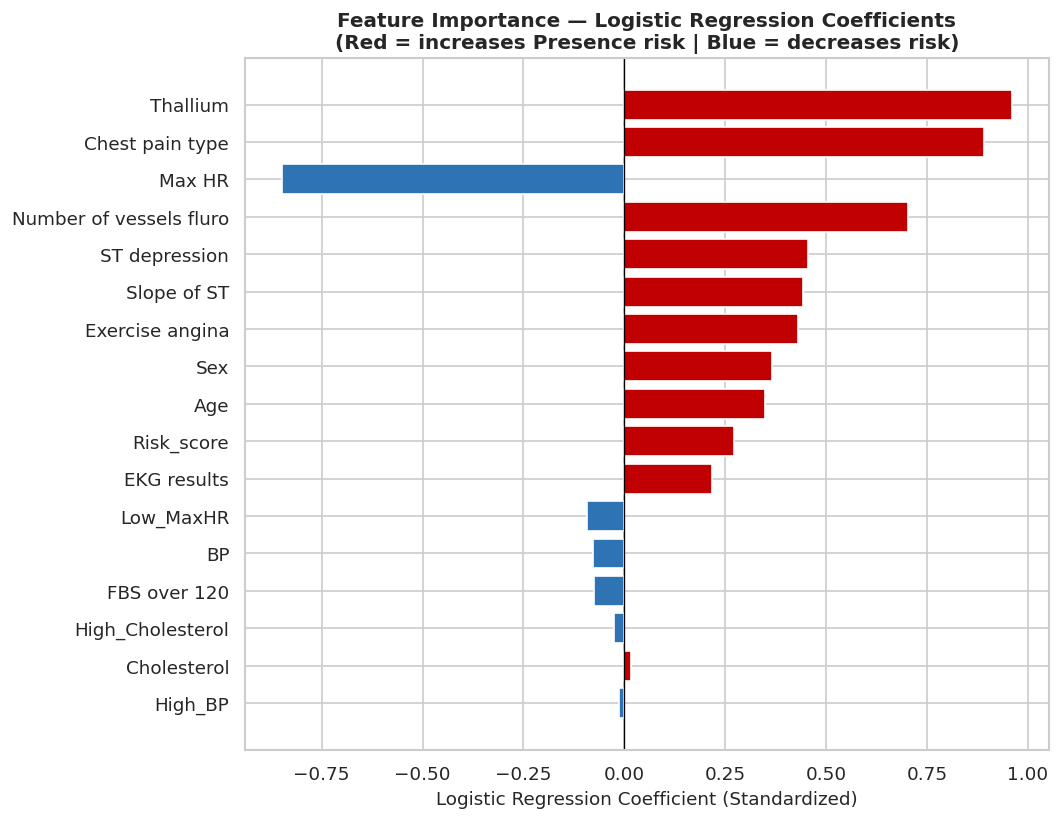

In [28]:
# Logistic regression coefficients represent feature importance
# Positive coefficient → increases probability of Presence
# Negative coefficient → decreases probability of Presence
coef_df = pd.DataFrame({'Feature': feature_cols, 'Coefficient': lr.coef_[0]})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=True).index)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#C00000' if c > 0 else '#2E74B5' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Logistic Regression Coefficient (Standardized)', fontsize=11)
ax.set_title('Feature Importance — Logistic Regression Coefficients\n(Red = increases Presence risk | Blue = decreases risk)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [29]:
# Display: Feature Importance

**Top Risk-Increasing Features (Red):**
1. **Thallium** — reversible defect result is the strongest predictor
2. **Chest Pain Type** — asymptomatic pain is counter-intuitively high risk
3. **Risk Score** — composite risk flag confirms additive risk
4. **ST Depression** — higher ST depression = higher risk
5. **Number of Vessels Fluro** — more blocked vessels = higher risk

**Top Risk-Decreasing Features (Blue):**
- **Max HR** — higher max heart rate = lower risk (healthy cardiac response)


## 17. Summary & Next Steps

### EDA Findings
- Dataset is **complete** — zero missing values, zero duplicates across 630,000 records.
- Classes are **nearly balanced** (55/45) — no resampling needed.
- **Max HR, Thallium, Chest Pain Type, ST Depression,** and **Number of Vessels Fluro** are the strongest individual predictors.
- The engineered **Risk Score** shows a near-monotonic relationship with heart disease rate (9.5% → 97.4%).
- Outliers exist in BP, ST Depression, and Max HR but are clinically valid — retained in the dataset.

### Baseline Model Results — Logistic Regression
| Metric | Score |
|--------|-------|
| Accuracy | 88.5% |
| Precision | 88.2% |
| Recall | 85.9% |
| F1 Score | 87.0% |
| **ROC-AUC** | **0.9516** |

The baseline model **exceeds** the target ROC-AUC of 0.90, confirming the features are highly informative even for a linear model.

### Next Steps (Module 24)
1. Train **XGBoost** and **LightGBM** ensemble models and benchmark against baseline
2. Perform **cross-validation** and hyperparameter tuning
3. Generate **SHAP values** for advanced feature interpretability
4. Prepare final presentation with business-friendly visualizations for non-technical audiences
5. Submit Kaggle predictions and evaluate leaderboard score
